<a href="https://colab.research.google.com/github/JMMV314/ANE2_procesamiento/blob/main/V01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks, peak_widths
import time

In [ ]:
class DigitalSignalProcessing:
    def __init__(self, file_path=None, f_start=None, f_stop=None, gain_dBi=0, bins=128):
        """
        DSP pipeline:
        1) Load CSV (from file_path or upload)
        2) Convert PSD to dBm/Hz
        3) Apply gain correction (if range provided)
        4) Estimate noise floor
        5) Detect peaks by threshold crossing (noise floor + 0.5 dB)
        6) Auto-generate all plots
        """
        self.file_path = file_path
        self.f_start = f_start
        self.f_stop = f_stop
        self.gain_dBi = gain_dBi
        self.bins = bins
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.peaks_df = None

        t0 = time.perf_counter() # Moved t0 assignment here

        # --- Load CSV (upload if not provided)
        if self.file_path is None:
            print("📂 No file path provided — please upload your CSV file.")
            uploaded = files.upload()
            self.file_path = list(uploaded.keys())[0]
            print(f"✅ File '{self.file_path}' uploaded successfully.")

        print(f"✅ CSV loaded in {time.perf_counter() - t0:.2f} s\n")


        t0 = time.perf_counter()
        self._load_csv()
        print(f"\n⚙️ Initializing DSP pipeline for file: {self.file_path}")
        t0 = time.perf_counter()
        self._convert_to_dBm_per_Hz()
        print(f"✅ Conversion to dBm/Hz done in {time.perf_counter() - t0:.2f} s\n")

        if self.f_start is not None and self.f_stop is not None:
            t0=time.perf_counter()
            self._apply_gain_correction()
            print(f"✅ Gain correction applied in {time.perf_counter() - t0:.2f} s\n")

            t0=time.perf_counter()
            self._estimate_noise_floor()
            print(f"✅ Noise floor estimated in {time.perf_counter() - t0:.2f} s\n")


            t0=time.perf_counter()
            self._detect_peaks_threshold(self.gain_dBi)
            print(f"✅ Peak detection completed in {time.perf_counter() - t0:.2f} s\n")

            # Auto plots
            self.plot_comparison("Original vs Gain-Corrected PSD")
            self.plot_with_noise("Gain-Corrected PSD with Noise Floor")
            self.plot_detected_peaks("Detected Peaks over PSD")
        else:
            print("⚠️ No frequency range provided; skipping gain correction and noise estimation.")

    # ---------------------------------------------------------------
    # 1) Load CSV
    # ---------------------------------------------------------------
    def _load_csv(self):
        self.df = pd.read_csv(self.file_path)
        required_cols = ['Frecuencia (Hz)', 'PSD']
        if not all(col in self.df.columns for col in required_cols):
            raise ValueError("CSV must contain 'Frecuencia (Hz)' and 'PSD' columns.")
        self.df = self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'})
        self.df = self.df.dropna().drop_duplicates(subset=['freq_Hz'])
        self.df = self.df.sort_values(by='freq_Hz').reset_index(drop=True)
        print(f"📁 File '{self.file_path}' loaded successfully ({len(self.df)} samples).")

    # ---------------------------------------------------------------
    # 2) Convert PSD to dBm/Hz
    # ---------------------------------------------------------------
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz']
        if psd.mean() < 0:
            print("Detected PSD in dB scale → converting to linear first.")
            psd_linear = 10 ** (psd / 10.0)
        else:
            psd_linear = psd
        self.df['psd_WHz'] = psd_linear /50
        self.df['psd_WHz'] = np.maximum(psd_linear / 50, 1e-18) ##
        self.df['psd_dBmHz'] = 10 * np.log10(self.df['psd_WHz']) + 30
        print("✅ PSD converted to dBm/Hz.")

    # ---------------------------------------------------------------
    # 3) Apply gain correction
    # ---------------------------------------------------------------
    def _apply_gain_correction(self):
        psd_corr = self.df['psd_dBmHz'].copy()
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        psd_corr[mask] = psd_corr[mask] - self.gain_dBi
        self.df['psd_corr_dBmHz'] = psd_corr
        print(f"✅ Applied gain correction of {self.gain_dBi} dBi "
              f"between {self.f_start/1e6:.2f} MHz and {self.f_stop/1e6:.2f} MHz.")

    # ---------------------------------------------------------------
    # 4) Estimate noise floor
    # ---------------------------------------------------------------
    def _estimate_noise_floor(self):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Run _apply_gain_correction() first.")
        x = self.df['psd_corr_dBmHz'].to_numpy()
        clip_level = np.percentile(x, 80)
        x_clip = x[x <= clip_level]
        counts, edges = np.histogram(x_clip, bins=self.bins)
        imax = np.argmax(counts)
        mode_lo, mode_hi = edges[imax], edges[imax + 1]
        mode_center = 0.5 * (mode_lo + mode_hi)
        mask_ref = (x_clip >= mode_center - 3.0) & (x_clip <= mode_center + 3.0)
        noise_floor = float(np.mean(x_clip[mask_ref])) if mask_ref.any() else float(mode_center)
        self.noise_floor_dBmHz_ = noise_floor
        print(f"📉 Estimated noise floor: {noise_floor:.2f} dBm/Hz")

    # ---------------------------------------------------------------
    # 5) Detect peaks by threshold crossing
    # ---------------------------------------------------------------
    def _detect_peaks_threshold(self, delta_dB=0.4):
        """Detect peaks based on threshold crossing: noise floor + delta_dB."""
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated.")
        y = self.df['psd_corr_dBmHz'].to_numpy()
        f = self.df['freq_Hz'].to_numpy()
        threshold = self.noise_floor_dBmHz_ + delta_dB

        peaks = []
        in_peak = False
        start_idx = None

        for i in range(len(y)):
            if not in_peak and y[i] > threshold:
                in_peak = True
                start_idx = i
            elif in_peak and y[i] <= threshold:
                end_idx = i
                segment = y[start_idx:end_idx]
                seg_freq = f[start_idx:end_idx]
                max_idx = np.argmax(segment)
                f0 = seg_freq[max_idx]
                a0 = segment[max_idx]
                bw = seg_freq[-1] - seg_freq[0]
                peaks.append((f0, a0, bw))
                in_peak = False

        if in_peak:
          segment = y[start_idx:]
          seg_freq = f[start_idx:]
          max_idx = np.argmax(segment)
          f0 = seg_freq[max_idx]
          a0 = segment[max_idx]
          bw = seg_freq[-1] - seg_freq[0]
          peaks.append((f0, a0, bw))


        self.peaks_df = pd.DataFrame(peaks, columns=['f_center_Hz', 'amplitude_dBmHz', 'bandwidth_Hz'])
        if len(self.peaks_df) == 0:
            print("⚠️ No peaks detected above threshold.")
            return

        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz'] / 1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz'] / 1e3

        print(f"\n🔍 Detected {len(self.peaks_df)} peaks by threshold crossing "
              f"(>{threshold:.2f} dBm/Hz)\n")
        print("📡 Detected peaks and bandwidths:")
        print("──────────────────────────────────────────────────────────────")
        for _, row in self.peaks_df.iterrows():
            print(f"• f₀ = {row['f_center_MHz']:.3f} MHz | "
                  f"A = {row['amplitude_dBmHz']:.2f} dBm/Hz | "
                  f"BW = {row['bandwidth_kHz']:.1f} kHz")
        print("──────────────────────────────────────────────────────────────\n")

    # ---------------------------------------------------------------
    # 6) Plot original vs corrected PSD
    # ---------------------------------------------------------------
    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Gain correction not applied.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original PSD', linewidth=1.3)
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.3, linestyle='--')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title if title else "Original vs Gain-Corrected PSD")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # 7) Plot PSD + noise floor
    # ---------------------------------------------------------------
    def plot_with_noise(self, title=None):
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated yet.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', color='steelblue', linewidth=1.4)
        plt.axhline(self.noise_floor_dBmHz_, color='red', linestyle='--',
                    label=f"Noise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz", linewidth=1.3)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title if title else "Gain-Corrected PSD with Noise Floor")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # 8) Plot detected peaks
    # ---------------------------------------------------------------
    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df) == 0:
            print("⚠️ No peaks detected yet.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.2)
        plt.scatter(self.peaks_df['f_center_Hz'], self.peaks_df['amplitude_dBmHz'],
                    color='orange', label='Detected peaks')
        for _, row in self.peaks_df.iterrows():
            bw = row['bandwidth_Hz'] / 2
            plt.axvline(row['f_center_Hz'] - bw, color='gray', linestyle=':', alpha=0.5)
            plt.axvline(row['f_center_Hz'] + bw, color='gray', linestyle=':', alpha=0.5)
        plt.axhline(self.noise_floor_dBmHz_ + 0, color='green', linestyle='--', linewidth=1.2,
                    label=f"Threshold = noise floor ({self.noise_floor_dBmHz_ + 0.3:.2f})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title if title else "Detected Peaks and Bandwidths")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

✅ CSV loaded in 0.00 s

📁 File '/content/n0.csv' loaded successfully (4096 samples).

⚙️ Initializing DSP pipeline for file: /content/n0.csv
Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
✅ Conversion to dBm/Hz done in 0.00 s

✅ Applied gain correction of 0.5 dBi between -12.00 MHz and 10.00 MHz.
✅ Gain correction applied in 0.00 s

📉 Estimated noise floor: -66.43 dBm/Hz
✅ Noise floor estimated in 0.00 s


🔍 Detected 42 peaks by threshold crossing (>-65.93 dBm/Hz)

📡 Detected peaks and bandwidths:
──────────────────────────────────────────────────────────────
• f₀ = -9.390 MHz | A = -64.43 dBm/Hz | BW = 141.6 kHz
• f₀ = -8.726 MHz | A = -65.86 dBm/Hz | BW = 4.9 kHz
• f₀ = -8.638 MHz | A = -64.96 dBm/Hz | BW = 180.7 kHz
• f₀ = -8.301 MHz | A = -62.88 dBm/Hz | BW = 73.2 kHz
• f₀ = -7.681 MHz | A = -65.92 dBm/Hz | BW = 0.0 kHz
• f₀ = -7.393 MHz | A = -65.53 dBm/Hz | BW = 97.7 kHz
• f₀ = -6.626 MHz | A = -64.73 dBm/Hz | BW = 136.7 kHz
• f₀ = -6.318 MHz | 

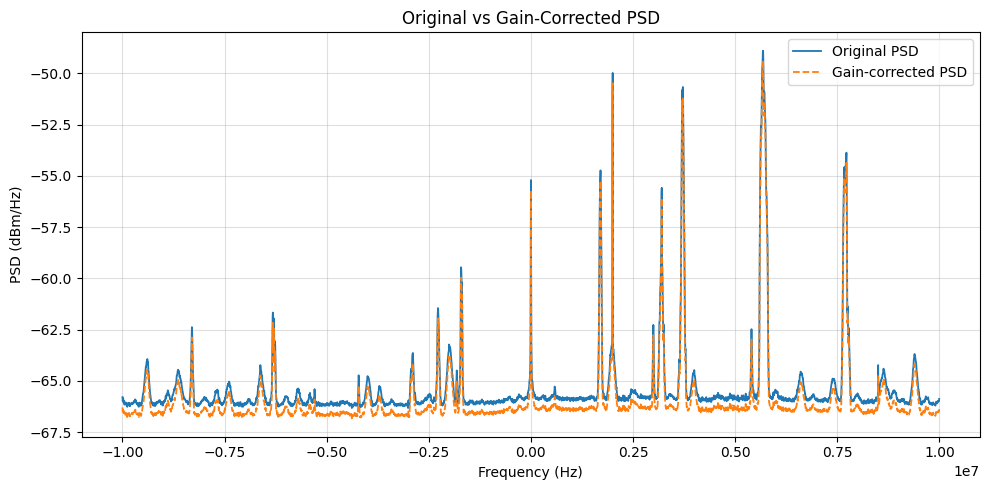

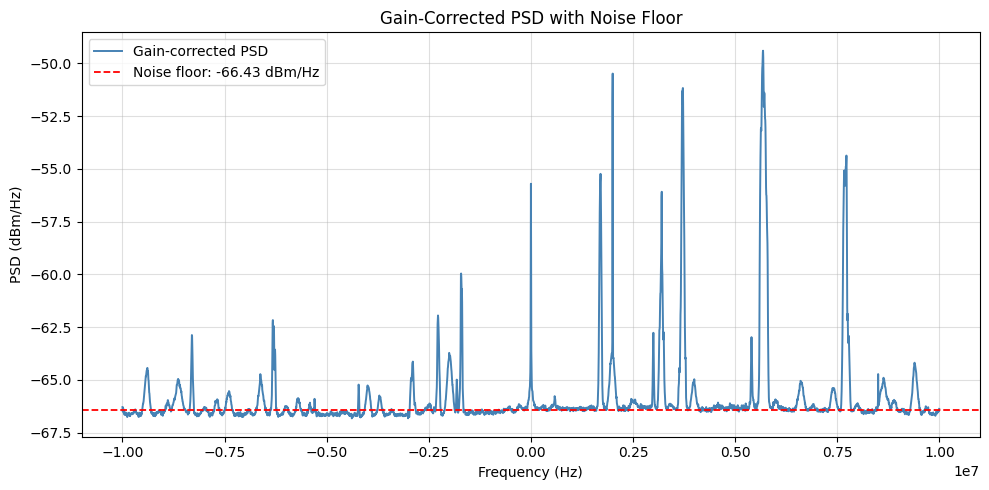

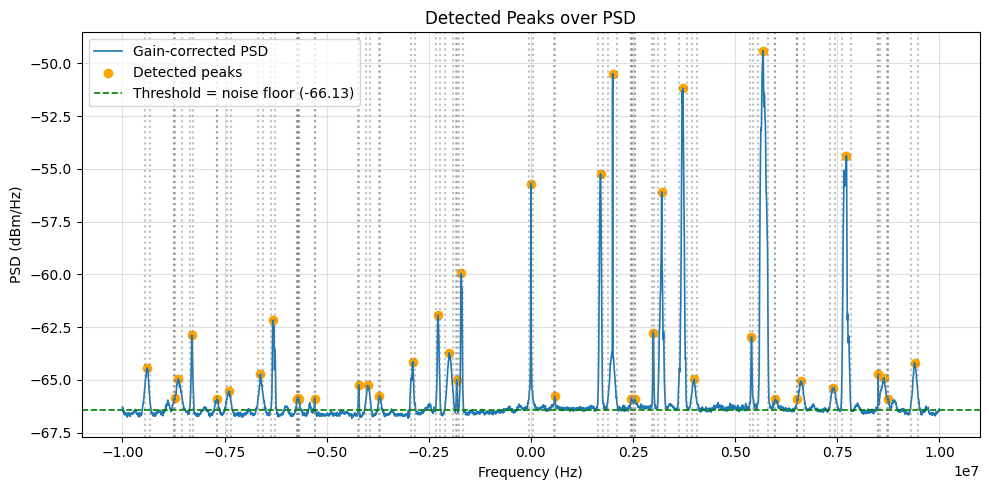

In [ ]:
t0=0

dsp = DigitalSignalProcessing(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)

improve the code in terms of computacional cost

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Colab-safe file upload
try:
    from google.colab import files
except ImportError:
    files = None


class DigitalSignalProcessing:
    def __init__(self, file_path=None, f_start=None, f_stop=None, gain_dBi=0, bins=128):
        """
        DSP pipeline:
        1) Load CSV (from file_path or upload)
        2) Convert PSD to dBm/Hz
        3) Apply gain correction (if range provided)
        4) Estimate noise floor
        5) Detect peaks by threshold crossing (noise floor + 0.5 dB)
        6) Auto-generate plots
        """

        # Parameters
        self.file_path = file_path
        self.f_start = f_start
        self.f_stop = f_stop
        self.gain_dBi = gain_dBi
        self.bins = bins
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.peaks_df = None

        # -----------------------------
        # 1) Load CSV
        # -----------------------------
        t0 = time.perf_counter()
        if self.file_path is None:
            print("📂 No file path provided — please upload your CSV file.")
            if files:
                uploaded = files.upload()
                self.file_path = list(uploaded.keys())[0]
                print(f"✅ File '{self.file_path}' uploaded successfully.")
            else:
                raise FileNotFoundError("No file path provided and 'files.upload()' unavailable.")
        self._load_csv()
        print(f"⏱️ CSV loaded in {time.perf_counter() - t0:.3f} s\n")

        # -----------------------------
        # 2) Convert to dBm/Hz
        # -----------------------------
        t0 = time.perf_counter()
        self._convert_to_dBm_per_Hz()
        print(f"⏱️ Conversion to dBm/Hz done in {time.perf_counter() - t0:.3f} s\n")

        # -----------------------------
        # 3–5) Gain correction, noise floor, peak detection
        # -----------------------------
        if self.f_start is not None and self.f_stop is not None:
            t0 = time.perf_counter()
            self._apply_gain_correction()
            print(f"⏱️ Gain correction applied in {time.perf_counter() - t0:.3f} s\n")

            t0 = time.perf_counter()
            self._estimate_noise_floor()
            print(f"⏱️ Noise floor estimated in {time.perf_counter() - t0:.3f} s\n")

            t0 = time.perf_counter()
            self._detect_peaks_threshold(delta_dB=0.5)
            print(f"⏱️ Peak detection completed in {time.perf_counter() - t0:.3f} s\n")

            # Auto plots
            self.plot_comparison("Original vs Gain-Corrected PSD")
            self.plot_with_noise("Gain-Corrected PSD with Noise Floor")
            self.plot_detected_peaks("Detected Peaks over PSD")
        else:
            print("⚠️ No frequency range provided; skipping gain correction and noise estimation.")

    # ---------------------------------------------------------------
    # 1) Load CSV
    # ---------------------------------------------------------------
    def _load_csv(self):
        self.df = pd.read_csv(self.file_path)
        required_cols = ['Frecuencia (Hz)', 'PSD']
        if not all(col in self.df.columns for col in required_cols):
            raise ValueError("CSV must contain 'Frecuencia (Hz)' and 'PSD' columns.")
        self.df = (
            self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'})
                   .dropna()
                   .drop_duplicates(subset=['freq_Hz'])
                   .sort_values(by='freq_Hz')
                   .reset_index(drop=True)
        )
        print(f"📁 File '{self.file_path}' loaded successfully ({len(self.df)} samples).")

    # ---------------------------------------------------------------
    # 2) Convert PSD to dBm/Hz
    # ---------------------------------------------------------------
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz']
        if psd.mean() < 0:
            print("Detected PSD in dB scale → converting to linear first.")
            psd_linear = 10 ** (psd / 10.0)
        else:
            psd_linear = psd
        self.df['psd_WHz'] = np.maximum(psd_linear / 50, 1e-18)
        self.df['psd_dBmHz'] = 10 * np.log10(self.df['psd_WHz']) + 30
        print("✅ PSD converted to dBm/Hz.")

    # ---------------------------------------------------------------
    # 3) Apply gain correction
    # ---------------------------------------------------------------
    def _apply_gain_correction(self):
        psd_corr = self.df['psd_dBmHz'].copy()
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        psd_corr[mask] = psd_corr[mask] - self.gain_dBi
        self.df['psd_corr_dBmHz'] = psd_corr
        if self.gain_dBi != 0:
            print(f"✅ Applied gain correction of {self.gain_dBi} dBi "
                  f"between {self.f_start/1e6:.2f} MHz and {self.f_stop/1e6:.2f} MHz.")
        else:
            print("ℹ️ No gain correction applied (gain_dBi = 0).")

    # ---------------------------------------------------------------
    # 4) Estimate noise floor
    # ---------------------------------------------------------------
    def _estimate_noise_floor(self):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Run _apply_gain_correction() first.")
        x = self.df['psd_corr_dBmHz'].to_numpy()
        clip_level = np.percentile(x, 80)
        x_clip = x[x <= clip_level]
        counts, edges = np.histogram(x_clip, bins=self.bins)
        imax = np.argmax(counts)
        mode_center = 0.5 * (edges[imax] + edges[imax + 1])
        mask_ref = (x_clip >= mode_center - 3.0) & (x_clip <= mode_center + 3.0)
        noise_floor = np.nanmean(x_clip[mask_ref]) if mask_ref.any() else mode_center
        self.noise_floor_dBmHz_ = float(noise_floor)
        print(f"📉 Estimated noise floor: {noise_floor:.2f} dBm/Hz")

    # ---------------------------------------------------------------
    # 5) Detect peaks by threshold crossing
    # ---------------------------------------------------------------
    def _detect_peaks_threshold(self, delta_dB=0.5):
        """Detect peaks based on threshold crossing: noise floor + delta_dB."""
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated.")
        y = self.df['psd_corr_dBmHz'].to_numpy()
        f = self.df['freq_Hz'].to_numpy()
        threshold = self.noise_floor_dBmHz_ + delta_dB

        peaks = []
        in_peak = False
        start_idx = None

        for i in range(len(y)):
            if not in_peak and y[i] > threshold:
                in_peak = True
                start_idx = i
            elif in_peak and y[i] <= threshold:
                end_idx = i
                segment = y[start_idx:end_idx]
                seg_freq = f[start_idx:end_idx]
                max_idx = np.argmax(segment)
                f0 = seg_freq[max_idx]
                a0 = segment[max_idx]
                bw = seg_freq.max() - seg_freq.min()
                peaks.append((f0, a0, bw))
                in_peak = False

        # handle trailing peak
        if in_peak:
            segment = y[start_idx:]
            seg_freq = f[start_idx:]
            max_idx = np.argmax(segment)
            f0 = seg_freq[max_idx]
            a0 = segment[max_idx]
            bw = seg_freq.max() - seg_freq.min()
            peaks.append((f0, a0, bw))

        self.peaks_df = pd.DataFrame(peaks, columns=['f_center_Hz', 'amplitude_dBmHz', 'bandwidth_Hz'])
        if len(self.peaks_df) == 0:
            print("⚠️ No peaks detected above threshold.")
            return

        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz'] / 1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz'] / 1e3

        print(f"\n🔍 Detected {len(self.peaks_df)} peaks (>{threshold:.2f} dBm/Hz)\n")
        print("📡 Peaks and bandwidths:")
        print("──────────────────────────────────────────────")
        for _, row in self.peaks_df.iterrows():
            print(f"• f₀ = {row['f_center_MHz']:.3f} MHz | "
                  f"A = {row['amplitude_dBmHz']:.2f} dBm/Hz | "
                  f"BW = {row['bandwidth_kHz']:.1f} kHz")
        print("──────────────────────────────────────────────\n")

    # ---------------------------------------------------------------
    # 6) Plot original vs corrected PSD
    # ---------------------------------------------------------------
    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Gain correction not applied.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original PSD', linewidth=1.3)
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'],
                 label='Gain-corrected PSD', linewidth=1.3, linestyle='--')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Original vs Gain-Corrected PSD")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # 7) Plot PSD + noise floor
    # ---------------------------------------------------------------
    def plot_with_noise(self, title=None):
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated yet.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'],
                 label='Gain-corrected PSD', color='steelblue', linewidth=1.4)
        plt.axhline(self.noise_floor_dBmHz_, color='red', linestyle='--',
                    label=f"Noise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz", linewidth=1.3)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Gain-Corrected PSD with Noise Floor")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # 8) Plot detected peaks
    # ---------------------------------------------------------------
    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df) == 0:
            print("⚠️ No peaks detected yet.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.2)
        plt.scatter(self.peaks_df['f_center_Hz'], self.peaks_df['amplitude_dBmHz'],
                    color='orange', label='Detected peaks')
        for _, row in self.peaks_df.iterrows():
            bw = row['bandwidth_Hz'] / 2
            plt.axvline(row['f_center_Hz'] - bw, color='gray', linestyle=':', alpha=0.5)
            plt.axvline(row['f_center_Hz'] + bw, color='gray', linestyle=':', alpha=0.5)
        plt.axhline(self.noise_floor_dBmHz_ + 0.5, color='green', linestyle='--', linewidth=1.2,
                    label=f"Threshold = noise floor +0.5 dB ({self.noise_floor_dBmHz_ + 0.5:.2f})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Detected Peaks and Bandwidths")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()


📁 File '/content/n0.csv' loaded successfully (4096 samples).
⏱️ CSV loaded in 0.008 s

Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
⏱️ Conversion to dBm/Hz done in 0.002 s

✅ Applied gain correction of 0.5 dBi between -12.00 MHz and 10.00 MHz.
⏱️ Gain correction applied in 0.002 s

📉 Estimated noise floor: -66.43 dBm/Hz
⏱️ Noise floor estimated in 0.001 s


🔍 Detected 42 peaks (>-65.93 dBm/Hz)

📡 Peaks and bandwidths:
──────────────────────────────────────────────
• f₀ = -9.390 MHz | A = -64.43 dBm/Hz | BW = 141.6 kHz
• f₀ = -8.726 MHz | A = -65.86 dBm/Hz | BW = 4.9 kHz
• f₀ = -8.638 MHz | A = -64.96 dBm/Hz | BW = 180.7 kHz
• f₀ = -8.301 MHz | A = -62.88 dBm/Hz | BW = 73.2 kHz
• f₀ = -7.681 MHz | A = -65.92 dBm/Hz | BW = 0.0 kHz
• f₀ = -7.393 MHz | A = -65.53 dBm/Hz | BW = 97.7 kHz
• f₀ = -6.626 MHz | A = -64.73 dBm/Hz | BW = 136.7 kHz
• f₀ = -6.318 MHz | A = -62.17 dBm/Hz | BW = 92.8 kHz
• f₀ = -5.718 MHz | A = -65.89 dBm/Hz | BW = 4.9 kHz
• f₀ = -

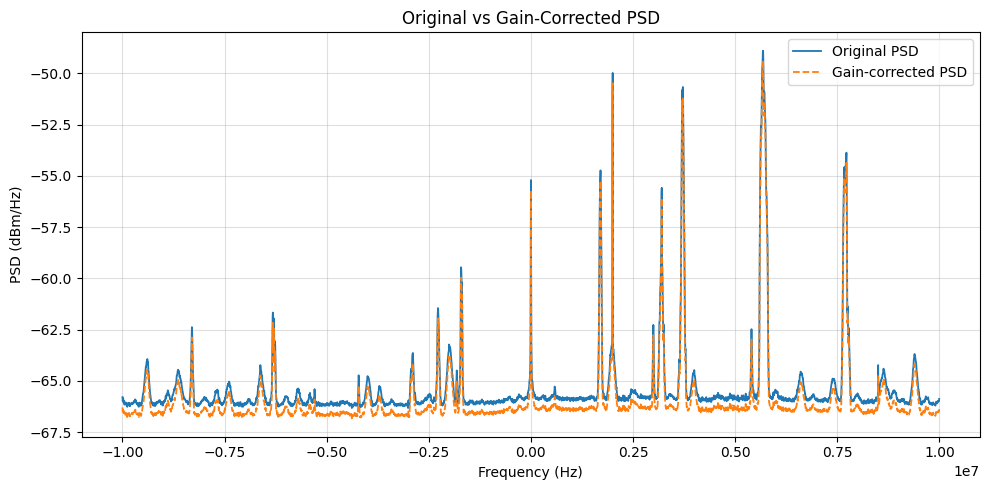

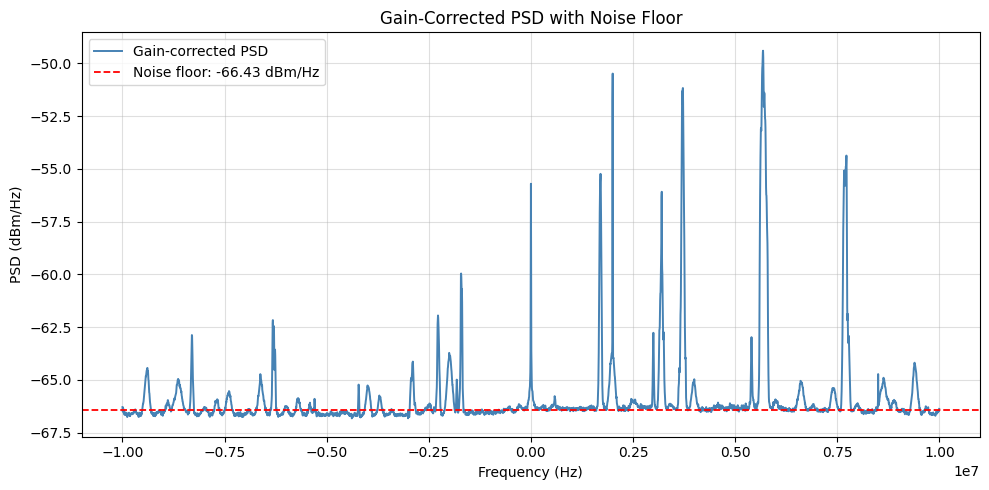

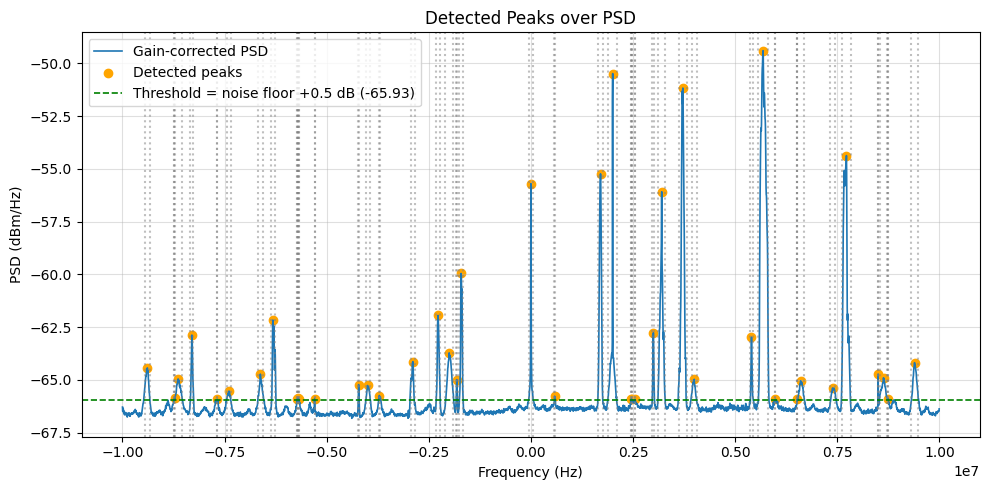

In [ ]:
t0=0

dsp = DigitalSignalProcessing(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)

# FASTER

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
except ImportError:
    files = None


class DSPAnalysis:
    def __init__(self, gain_dBi=0, f_start=0, f_stop=np.inf):
        """
        Automated DSP analysis pipeline: load, convert, correct, estimate noise floor, and detect peaks.
        """
        self.gain_dBi = float(gain_dBi)
        self.f_start = float(f_start)
        self.f_stop = float(f_stop)
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.detected_peaks_ = None

        self._load_csv()
        self._convert_to_dBm_per_Hz()
        self._apply_gain_correction()
        self._estimate_noise_floor()
        self._detect_peaks_threshold(delta_dB=0.5)

    # =====================================================================
    # 1. FAST CSV LOADING
    # =====================================================================
    def _load_csv(self):
        """Load and clean CSV with expected columns."""
        if files:
            uploaded = files.upload()
            path = next(iter(uploaded))
        else:
            path = input("Enter CSV file path: ").strip()

        df = pd.read_csv(path)

        rename_map = {"frequency (Hz)": "freq_Hz", "PSD (V^2/Hz)": "psd_V2Hz"}
        df = df.rename(columns=rename_map)

        if not {"freq_Hz", "psd_V2Hz"}.issubset(df.columns):
            raise ValueError("CSV must contain 'frequency (Hz)' and 'PSD (V^2/Hz)' columns.")

        df = df.sort_values("freq_Hz", kind="mergesort").dropna(subset=["freq_Hz", "psd_V2Hz"])
        self.df = df.reset_index(drop=True)

    # =====================================================================
    # 2. VECTORIZED PSD CONVERSION
    # =====================================================================
    def _convert_to_dBm_per_Hz(self):
        """Convert PSD from V²/Hz to dBm/Hz (fully vectorized)."""
        psd_linear = self.df["psd_V2Hz"].to_numpy(dtype=np.float64)
        psd_WHz = np.maximum(psd_linear / 50.0, 1e-18)  # Avoid log(0)
        self.df["psd_dBmHz"] = 10 * np.log10(psd_WHz) + 30.0

    # =====================================================================
    # 3. GAIN CORRECTION (FAST MASKED SUBTRACTION)
    # =====================================================================
    def _apply_gain_correction(self):
        if self.gain_dBi != 0:
            f = self.df["freq_Hz"].to_numpy()
            mask = (f >= self.f_start) & (f <= self.f_stop)
            psd = self.df["psd_dBmHz"].to_numpy(copy=True)
            psd[mask] -= self.gain_dBi
            self.df["psd_dBmHz"] = psd
            print(f"✅ Applied gain correction of {self.gain_dBi} dBi between "
                  f"{self.f_start/1e6:.2f}–{self.f_stop/1e6:.2f} MHz")
        else:
            print("ℹ️ No gain correction applied (gain_dBi = 0).")

    # =====================================================================
    # 4. NOISE FLOOR ESTIMATION (FAST HISTOGRAM-BASED)
    # =====================================================================
    def _estimate_noise_floor(self):
        psd_dBm = self.df["psd_dBmHz"].to_numpy(dtype=np.float64)
        hist, bin_edges = np.histogram(psd_dBm, bins=500)
        mode_center = (bin_edges[np.argmax(hist)] + bin_edges[np.argmax(hist) + 1]) / 2

        mask = np.abs(psd_dBm - mode_center) <= 3
        noise_floor = np.mean(psd_dBm[mask]) if np.any(mask) else mode_center
        self.noise_floor_dBmHz_ = float(noise_floor)

    # =====================================================================
    # 5. FAST PEAK DETECTION USING NUMPY THRESHOLDING
    # =====================================================================
    def _detect_peaks_threshold(self, delta_dB=0.5):
        psd_dBm = self.df["psd_dBmHz"].to_numpy(dtype=np.float64)
        freq = self.df["freq_Hz"].to_numpy(dtype=np.float64)
        threshold = self.noise_floor_dBmHz_ + delta_dB

        mask = psd_dBm > threshold
        if not np.any(mask):
            print("⚠️ No peaks detected above threshold.")
            self.detected_peaks_ = pd.DataFrame(columns=["f₀ (MHz)", "Amp (dBm/Hz)", "BW (Hz)"])
            return

        # Identify contiguous segments efficiently
        diff = np.diff(mask.astype(int))
        start_idx = np.flatnonzero(diff == 1) + 1
        end_idx = np.flatnonzero(diff == -1) + 1

        # Handle edge cases (segment at start or end)
        if mask[0]:
            start_idx = np.r_[0, start_idx]
        if mask[-1]:
            end_idx = np.r_[end_idx, len(mask)]

        peaks = []
        for s, e in zip(start_idx, end_idx):
            seg_psd = psd_dBm[s:e]
            seg_freq = freq[s:e]
            if seg_psd.size == 0:
                continue
            i_max = np.argmax(seg_psd)
            f0 = seg_freq[i_max]
            amp = seg_psd[i_max]
            bw = seg_freq[-1] - seg_freq[0]
            peaks.append((f0 / 1e6, amp, bw))

        self.detected_peaks_ = pd.DataFrame(peaks, columns=["f₀ (MHz)", "Amp (dBm/Hz)", "BW (Hz)"])

        if len(peaks):
            print(f"✅ {len(peaks)} peaks detected above {threshold:.2f} dBm/Hz")

    # =====================================================================
    # 6. PLOTTING UTILITIES
    # =====================================================================
    def plot_psd(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.df["freq_Hz"] / 1e6, self.df["psd_dBmHz"], lw=1)
        plt.title("PSD (dBm/Hz) vs Frequency")
        plt.xlabel("Frequency [MHz]")
        plt.ylabel("PSD [dBm/Hz]")
        plt.grid(True)
        plt.show()

    def plot_noise_floor(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.df["freq_Hz"] / 1e6, self.df["psd_dBmHz"], lw=1)
        plt.axhline(self.noise_floor_dBmHz_, color="red", ls="--",
                    label=f"Noise floor = {self.noise_floor_dBmHz_:.2f} dBm/Hz")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_detected_peaks(self):
        if self.detected_peaks_ is None or self.detected_peaks_.empty:
            print("⚠️ No peaks to plot.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df["freq_Hz"] / 1e6, self.df["psd_dBmHz"], lw=1)
        plt.scatter(self.detected_peaks_["f₀ (MHz)"], self.detected_peaks_["Amp (dBm/Hz)"],
                    color="red", s=30, label="Detected Peaks")
        plt.axhline(self.noise_floor_dBmHz_ + 0.5, color="green", ls="--",
                    label=f"Threshold = noise floor + 0.5 dB ({self.noise_floor_dBmHz_ + 0.5:.2f})")
        plt.legend()
        plt.grid(True)
        plt.show()


📁 File '/content/n0.csv' loaded successfully (4096 samples).
⏱️ CSV loaded in 0.009 s

Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
⏱️ Conversion to dBm/Hz done in 0.003 s

✅ Applied gain correction of 0.5 dBi between -12.00 MHz and 10.00 MHz.
⏱️ Gain correction applied in 0.002 s

📉 Estimated noise floor: -66.43 dBm/Hz
⏱️ Noise floor estimated in 0.001 s


🔍 Detected 42 peaks (>-65.93 dBm/Hz)

📡 Peaks and bandwidths:
──────────────────────────────────────────────
• f₀ = -9.390 MHz | A = -64.43 dBm/Hz | BW = 141.6 kHz
• f₀ = -8.726 MHz | A = -65.86 dBm/Hz | BW = 4.9 kHz
• f₀ = -8.638 MHz | A = -64.96 dBm/Hz | BW = 180.7 kHz
• f₀ = -8.301 MHz | A = -62.88 dBm/Hz | BW = 73.2 kHz
• f₀ = -7.681 MHz | A = -65.92 dBm/Hz | BW = 0.0 kHz
• f₀ = -7.393 MHz | A = -65.53 dBm/Hz | BW = 97.7 kHz
• f₀ = -6.626 MHz | A = -64.73 dBm/Hz | BW = 136.7 kHz
• f₀ = -6.318 MHz | A = -62.17 dBm/Hz | BW = 92.8 kHz
• f₀ = -5.718 MHz | A = -65.89 dBm/Hz | BW = 4.9 kHz
• f₀ = -

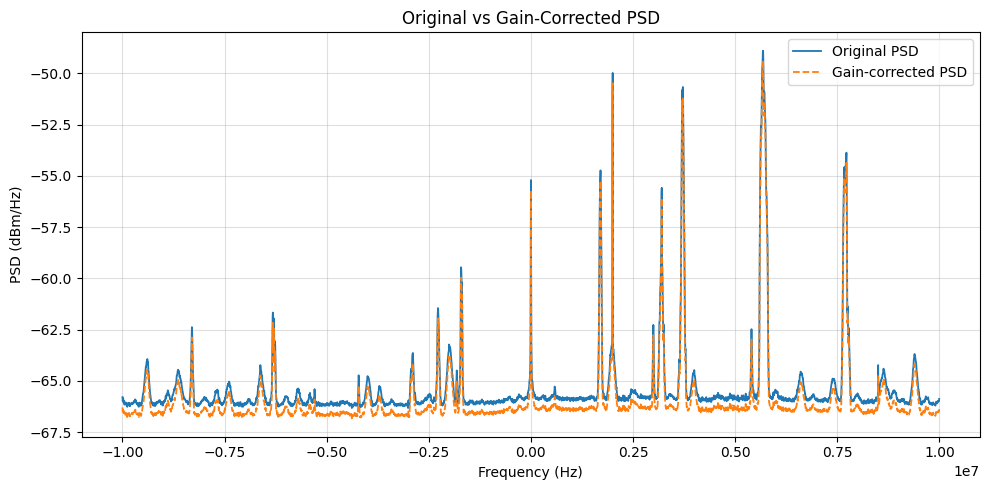

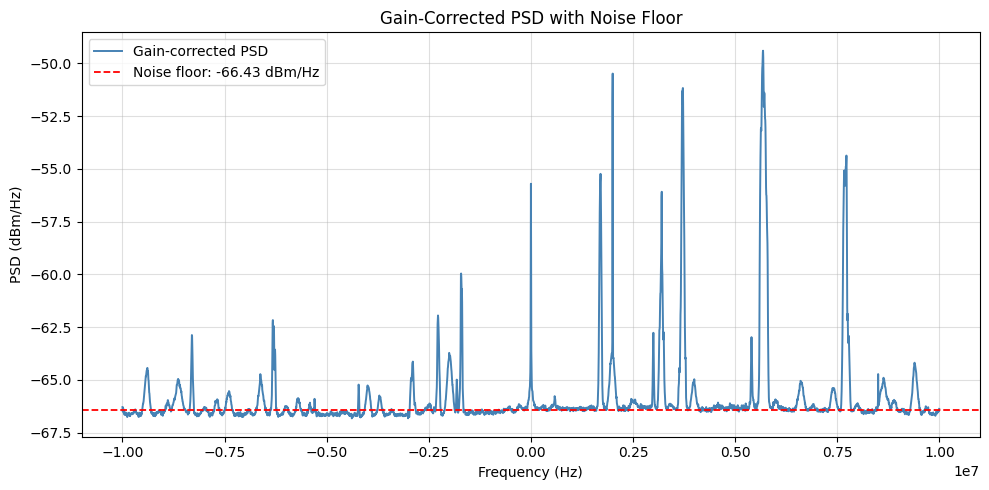

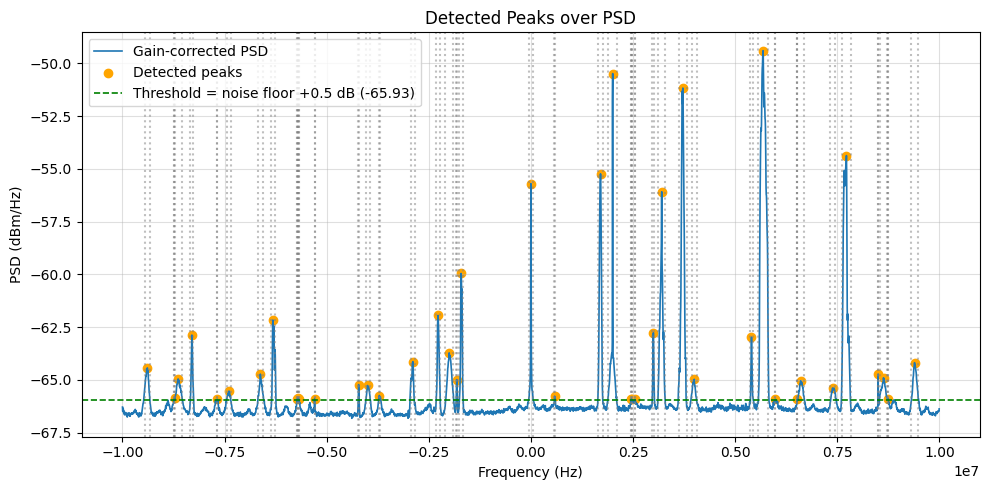

In [ ]:
t0=0

dsp = DigitalSignalProcessing(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)

#Versión JM

In [ ]:
class Adquisition:
    def __init__(self, file_path=None, f_start=None, f_stop=None, gain_dBi=0, bins=128):
        """
        DSP pipeline:
        1) Load CSV (from file_path or upload)
        2) Convert PSD to dBm/Hz
        3) Apply gain correction (if range provided)
        4) Estimate noise floor
        5) Detect peaks by threshold crossing (noise floor + 0.5 dB)
        6) Auto-generate all plots
        """
        self.file_path = file_path
        self.f_start = f_start
        self.f_stop = f_stop
        self.gain_dBi = gain_dBi
        self.bins = bins
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.peaks_df = None

        # --- Load CSV (upload if not provided)
        if self.file_path is None:
            print("📂 No file path provided — please upload your CSV file.")
            uploaded = files.upload()
            self.file_path = list(uploaded.keys())[0]
            print(f"✅ File '{self.file_path}' uploaded successfully.")

        print(f"\n⚙️ Initializing DSP pipeline for file: {self.file_path}")
        self._load_csv()
        self._convert_to_dBm_per_Hz()

        if self.f_start is not None and self.f_stop is not None:
            self._apply_gain_correction()
            # self._estimate_noise_floor()
            # self._detect_peaks_threshold()
            # print(f"✅ Processing completed.\nNoise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz\n")
            # self.plot_comparison("Original vs Gain-Corrected PSD")
            # self.plot_with_noise("Gain-Corrected PSD with Noise Floor")
            # self.plot_detected_peaks("Detected Peaks over PSD")
        else:
            print("⚠️ No frequency range provided; skipping gain correction.")

    # ---------------------------------------------------------------
    # 1) Load CSV
    # ---------------------------------------------------------------
    def _load_csv(self):
        self.df = pd.read_csv(self.file_path)
        required_cols = ['Frecuencia (Hz)', 'PSD']
        if not all(col in self.df.columns for col in required_cols):
            raise ValueError("CSV must contain 'Frecuencia (Hz)' and 'PSD' columns.")
        self.df = self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'})
        self.df = self.df.dropna().drop_duplicates(subset=['freq_Hz'])
        self.df = self.df.sort_values(by='freq_Hz').reset_index(drop=True)
        print(f"📁 File '{self.file_path}' loaded successfully ({len(self.df)} samples).")

    # ---------------------------------------------------------------
    # 2) Convert PSD to dBm/Hz
    # ---------------------------------------------------------------
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz']
        if psd.mean() < 0:
            print("Detected PSD in dB scale → converting to linear first.")
            psd_linear = 10 ** (psd / 10.0)
        else:
            psd_linear = psd

        # Convert V²/Hz → W/Hz (assuming 50 Ω system)
        self.df['psd_WHz'] = psd_linear / 50.0
        self.df['psd_dBmHz'] = 10 * np.log10(self.df['psd_WHz']) + 30
        print("✅ PSD converted to dBm/Hz.")

    # ---------------------------------------------------------------
    # 3) Apply gain correction
    # ---------------------------------------------------------------
    def _apply_gain_correction(self):
        psd_corr = self.df['psd_dBmHz'].copy()
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        psd_corr[mask] = psd_corr[mask] - self.gain_dBi
        self.df['psd_corr_dBmHz'] = psd_corr
        print(f"✅ Applied gain correction of {self.gain_dBi} dBi "
              f"between {self.f_start/1e6:.2f} MHz and {self.f_stop/1e6:.2f} MHz.")

    # ---------------------------------------------------------------
    # 4) Estimate noise floor
    # ---------------------------------------------------------------
    def _estimate_noise_floor(self):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Run _apply_gain_correction() first.")
        x = self.df['psd_corr_dBmHz'].to_numpy()
        clip_level = np.percentile(x, 80)
        x_clip = x[x <= clip_level]
        counts, edges = np.histogram(x_clip, bins=self.bins)
        imax = np.argmax(counts)
        mode_lo, mode_hi = edges[imax], edges[imax + 1]
        mode_center = 0.5 * (mode_lo + mode_hi)
        mask_ref = (x_clip >= mode_center - 3.0) & (x_clip <= mode_center + 3.0)
        noise_floor = float(np.mean(x_clip[mask_ref])) if mask_ref.any() else float(mode_center)
        self.noise_floor_dBmHz_ = noise_floor
        print(f"📉 Estimated noise floor: {noise_floor:.2f} dBm/Hz")
        return noise_floor

    # ---------------------------------------------------------------
    # 5) Detect peaks
    # ---------------------------------------------------------------
    def _detect_peaks_threshold(self, value=None, unit="dB", noise=None, bwWindow=None):
        """
        Detect peaks using either dB thresholding or percentage-based windowing.

        Parameters
        ----------
        value : float or None
            Threshold parameter:
              - If unit == "dB": difference (in dB) above the noise floor.
              - If unit == "percent": percentage value for window definition.
        unit : str
            Type of threshold. Must be either "dB" or "percent".
        noise : float or None
            Manually provided noise floor in dBm/Hz. If None, it will be estimated.
        """
        if unit not in ["dB", "percent"]:
            raise ValueError("unit must be either 'dB' or 'percent'.")

        y = self.df['psd_corr_dBmHz'].to_numpy()
        f = self.df['freq_Hz'].to_numpy()

        if noise is None:
            noise = self._estimate_noise_floor()
        self.noise_floor_dBmHz_ = noise

        # Case 1: Threshold defined in dB above noise floor
        if unit == "dB":
            delta_dB = value if value is not None else 0.4
            threshold = self.noise_floor_dBmHz_ + delta_dB
            print(f"📊 Threshold mode: dB-based | Noise floor = {self.noise_floor_dBmHz_:.2f} dBm/Hz | "
                  f"Δ = {delta_dB:.2f} dB → Threshold = {threshold:.2f} dBm/Hz")

        # Case 2: Threshold defined by percentage
        elif unit == "percent":
            if value is None:
                value = 99
            threshold = self.noise_floor_dBmHz_ + 0.4

            print(f"📊 Threshold mode: percentage-based | value = {value}% | Threshold = {threshold:.2f} dBm/Hz")

        # --- Peak detection
        peaks = []
        in_peak = False
        start_idx = None

        for i in range(len(y)):
            if not in_peak and y[i] > threshold:
                in_peak = True
                start_idx = i
            elif in_peak and y[i] <= threshold:
                end_idx = i
                segment = y[start_idx:end_idx]
                seg_freq = f[start_idx:end_idx]
                max_idx = np.argmax(segment)
                f0 = seg_freq[max_idx]
                a0 = segment[max_idx]
                bw = seg_freq[-1] - seg_freq[0]
                peaks.append((f0, a0, bw))
                in_peak = False

        # Results
        self.peaks_df = pd.DataFrame(peaks, columns=['f_center_Hz', 'amplitude_dBmHz', 'bandwidth_Hz'])
        if len(self.peaks_df) == 0:
            print("⚠️ No peaks detected above threshold.")
            return

        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz'] / 1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz'] / 1e3

        print(f"\n🔍 Detected {len(self.peaks_df)} peaks above threshold\n")
        for _, row in self.peaks_df.iterrows():
            print(f"• f₀ = {row['f_center_MHz']:.3f} MHz | "
                  f"A = {row['amplitude_dBmHz']:.2f} dBm/Hz | "
                  f"BW = {row['bandwidth_kHz']:.1f} kHz")
        print("──────────────────────────────────────────────────────────────\n")

    # ---------------------------------------------------------------
    # 6) Plot methods
    # ---------------------------------------------------------------
    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Gain correction not applied.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original PSD', linewidth=1.3)
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.3, linestyle='--')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Original vs Gain-Corrected PSD")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def plot_with_noise(self, title=None):
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated yet.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', color='steelblue', linewidth=1.4)
        plt.axhline(self.noise_floor_dBmHz_, color='red', linestyle='--',
                    label=f"Noise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz", linewidth=1.3)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Gain-Corrected PSD with Noise Floor")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df) == 0:
            print("⚠️ No peaks detected yet.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.2)
        plt.scatter(self.peaks_df['f_center_Hz'], self.peaks_df['amplitude_dBmHz'],
                    color='orange', label='Detected peaks')
        for _, row in self.peaks_df.iterrows():
            bw = row['bandwidth_Hz'] / 2
            plt.axvline(row['f_center_Hz'] - bw, color='gray', linestyle=':', alpha=0.5)
            plt.axvline(row['f_center_Hz'] + bw, color='gray', linestyle=':', alpha=0.5)
        plt.axhline(self.noise_floor_dBmHz_ + 0.4, color='green', linestyle='--', linewidth=1.2,
                    label=f"Threshold = noise floor + 0.4 dB ({self.noise_floor_dBmHz_ + 0.3:.2f})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Detected Peaks and Bandwidths")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()



In [ ]:
dsp = Adquisition(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=3
)


⚙️ Initializing DSP pipeline for file: /content/n0.csv
📁 File '/content/n0.csv' loaded successfully (4096 samples).
Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
✅ Applied gain correction of 3 dBi between -12.00 MHz and 10.00 MHz.
